<a href="https://colab.research.google.com/github/Greeshma-babu/AI_Projects/blob/main/DCGAN_Cartoon_Character_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install torch torchvision matplotlib

In [3]:
from google.colab import files

uploaded = files.upload()

Saving pokemon.zip to pokemon.zip


In [4]:
import zipfile
import os

zip_path = "/content/pokemon.zip"  # Change if needed
extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
#%% md
# DCGAN Cartoon Character Generation
# This notebook trains a DCGAN on an ImageFolder dataset.
#%%

#%%
import os, torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

device='cuda' if torch.cuda.is_available() else 'cpu'
image_size=64
batch_size=32
nz=100
ngf=64
ndf=64
epochs=50
lr=0.0002

transform=transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset=datasets.ImageFolder('/content/dataset',transform=transform)
loader=DataLoader(dataset,batch_size=batch_size,shuffle=True)

#%%
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main=nn.Sequential(
            nn.ConvTranspose2d(nz,ngf*8,4,1,0,bias=False),
            nn.BatchNorm2d(ngf*8),nn.ReLU(True),
            nn.ConvTranspose2d(ngf*8,ngf*4,4,2,1,bias=False),
            nn.BatchNorm2d(ngf*4),nn.ReLU(True),
            nn.ConvTranspose2d(ngf*4,ngf*2,4,2,1,bias=False),
            nn.BatchNorm2d(ngf*2),nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2,ngf,4,2,1,bias=False),
            nn.BatchNorm2d(ngf),nn.ReLU(True),
            nn.ConvTranspose2d(ngf,3,4,2,1,bias=False),
            nn.Tanh())
    def forward(self,x): return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.main=nn.Sequential(
            nn.Conv2d(3,ndf,4,2,1,bias=False),nn.LeakyReLU(.2,True),
            nn.Conv2d(ndf,ndf*2,4,2,1,bias=False),nn.BatchNorm2d(ndf*2),nn.LeakyReLU(.2,True),
            nn.Conv2d(ndf*2,ndf*4,4,2,1,bias=False),nn.BatchNorm2d(ndf*4),nn.LeakyReLU(.2,True),
            nn.Conv2d(ndf*4,ndf*8,4,2,1,bias=False),nn.BatchNorm2d(ndf*8),nn.LeakyReLU(.2,True),
            nn.Conv2d(ndf*8,1,4,1,0,bias=False),nn.Sigmoid())
    def forward(self,x): return self.main(x).view(-1)

#%%
def weights_init(m):
    n=m.__class__.__name__
    if 'Conv' in n: nn.init.normal_(m.weight.data,0,0.02)
    elif 'BatchNorm' in n:
        nn.init.normal_(m.weight.data,1,0.02)
        nn.init.constant_(m.bias.data,0)

G=Generator().to(device);D=Discriminator().to(device)
G.apply(weights_init);D.apply(weights_init)
criterion=nn.BCELoss()
optG=optim.Adam(G.parameters(),lr=lr,betas=(0.5,0.999))
optD=optim.Adam(D.parameters(),lr=lr,betas=(0.5,0.999))
fixed=torch.randn(64,nz,1,1,device=device)
g_losses=[];d_losses=[]
os.makedirs('generated',exist_ok=True)

for epoch in range(epochs):
    for real,_ in loader:
        real=real.to(device);b=real.size(0)
        D.zero_grad()
        lbl=torch.ones(b,device=device)
        out=D(real);lossR=criterion(out,lbl)
        noise=torch.randn(b,nz,1,1,device=device)
        fake=G(noise)
        lbl.fill_(0)
        out=D(fake.detach());lossF=criterion(out,lbl)
        lossD=lossR+lossF;lossD.backward();optD.step()
        G.zero_grad()
        lbl.fill_(1)
        out=D(fake);lossG=criterion(out,lbl)
        lossG.backward();optG.step()
    g_losses.append(lossG.item());d_losses.append(lossD.item())
    with torch.no_grad():
        imgs=G(fixed).cpu()
    utils.save_image(imgs,f'generated/epoch_{epoch+1}.png',normalize=True)
    print(epoch+1,lossD.item(),lossG.item())
torch.save(G.state_dict(),'generator.pth')

#%%
plt.plot(g_losses,label='G');plt.plot(d_losses,label='D');plt.legend();plt.show()

G.load_state_dict(torch.load('generator.pth',map_location=device))
G.eval()
with torch.no_grad():
    fake=G(torch.randn(16,nz,1,1,device=device)).cpu()
plt.figure(figsize=(6,6))
plt.axis('off')
plt.imshow(utils.make_grid(fake,normalize=True,nrow=4).permute(1,2,0))
plt.show()


RuntimeError: one of the variables needed for gradient computation has been modified by an inplace operation: [torch.FloatTensor [32]] is at version 1; expected version 0 instead. Hint: enable anomaly detection to find the operation that failed to compute its gradient, with torch.autograd.set_detect_anomaly(True, check_nan=False).

In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [27]:
image_size = 64
batch_size = 32

nz = 100        # Noise vector size
ngf = 64        # Generator feature maps
ndf = 64        # Discriminator feature maps

epochs = 100
lr = 0.0002

In [28]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),
                         (0.5,0.5,0.5))
])

dataset = datasets.ImageFolder(
    "/content/dataset",
    transform=transform
)

loader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

print("Classes:", dataset.classes)
print("Images:", len(dataset))

Classes: ['pokemon']
Images: 819


In [29]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.main = nn.Sequential(

            nn.ConvTranspose2d(nz, ngf*8,4,1,0,bias=False),
            nn.BatchNorm2d(ngf*8),
            nn.ReLU(),

            nn.ConvTranspose2d(ngf*8,ngf*4,4,2,1,bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(),

            nn.ConvTranspose2d(ngf*4,ngf*2,4,2,1,bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(),

            nn.ConvTranspose2d(ngf*2,ngf,4,2,1,bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(),

            nn.ConvTranspose2d(ngf,3,4,2,1,bias=False),
            nn.Tanh()

        )

    def forward(self,x):

        return self.main(x)

In [30]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.main = nn.Sequential(

            nn.Conv2d(3,ndf,4,2,1,bias=False),
            nn.LeakyReLU(0.2),

            nn.Conv2d(ndf,ndf*2,4,2,1,bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2),

            nn.Conv2d(ndf*2,ndf*4,4,2,1,bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2),

            nn.Conv2d(ndf*4,ndf*8,4,2,1,bias=False),
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2),

            nn.Conv2d(ndf*8,1,4,1,0,bias=False),
            nn.Sigmoid()

        )

    def forward(self,x):

        return self.main(x).view(-1)

In [31]:
def weights_init(m):

    classname = m.__class__.__name__

    if classname.find("Conv") != -1:

        nn.init.normal_(m.weight.data,0.0,0.02)

    elif classname.find("BatchNorm") != -1:

        nn.init.normal_(m.weight.data,1.0,0.02)
        nn.init.constant_(m.bias.data,0)

In [32]:
G = Generator().to(device)
D = Discriminator().to(device)

G.apply(weights_init)
D.apply(weights_init)

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )
)

In [33]:
criterion = nn.BCELoss()

optimizerG = optim.Adam(
    G.parameters(),
    lr=lr,
    betas=(0.5,0.999)
)

optimizerD = optim.Adam(
    D.parameters(),
    lr=lr,
    betas=(0.5,0.999)
)

In [34]:
fixed_noise = torch.randn(64,nz,1,1,device=device)

g_losses = []
d_losses = []

os.makedirs("generated",exist_ok=True)

for epoch in range(epochs):

    for real,_ in loader:

        real = real.to(device)

        b = real.size(0)

        ################################################
        # Train Discriminator
        ################################################

        optimizerD.zero_grad()


        real_labels = torch.ones(b,device=device)

        fake_labels = torch.zeros(b,device=device)

        output_real = D(real)

        loss_real = criterion(
            output_real,
            real_labels
        )

        noise = torch.randn(
            b,
            nz,
            1,
            1,
            device=device
        )

        fake = G(noise)

        output_fake = D(fake.detach())

        loss_fake = criterion(
            output_fake,
            fake_labels
        )

        lossD = loss_real + loss_fake

        lossD.backward()

        optimizerD.step()

        ################################################
        # Train Generator
        ################################################

        optimizerG.zero_grad()

        noise = torch.randn(
            b,
            nz,
            1,
            1,
            device=device
        )

        fake = G(noise)

        output = D(fake)

        lossG = criterion(
            output,
            real_labels
        )

        lossG.backward()

        optimizerG.step()

    g_losses.append(lossG.item())
    d_losses.append(lossD.item())

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"D Loss: {lossD.item():.4f} "
        f"G Loss: {lossG.item():.4f}"
    )

    with torch.no_grad():

        fake = G(fixed_noise).cpu()

        utils.save_image(
            fake,
            f"generated/epoch_{epoch+1}.png",
            normalize=True,
            nrow=8
        )

Epoch [1/100] D Loss: 0.4044 G Loss: 8.3102
Epoch [2/100] D Loss: 0.8713 G Loss: 16.9273
Epoch [3/100] D Loss: 1.5277 G Loss: 4.7890
Epoch [4/100] D Loss: 0.3559 G Loss: 2.0834
Epoch [5/100] D Loss: 0.7830 G Loss: 4.7225
Epoch [6/100] D Loss: 1.3359 G Loss: 8.4263
Epoch [7/100] D Loss: 0.5658 G Loss: 6.1743
Epoch [8/100] D Loss: 0.3708 G Loss: 4.2746
Epoch [9/100] D Loss: 0.4483 G Loss: 3.7873
Epoch [10/100] D Loss: 0.2838 G Loss: 5.7730
Epoch [11/100] D Loss: 0.1775 G Loss: 5.3929
Epoch [12/100] D Loss: 0.5931 G Loss: 2.2533
Epoch [13/100] D Loss: 0.3451 G Loss: 3.5336
Epoch [14/100] D Loss: 0.9119 G Loss: 2.1942
Epoch [15/100] D Loss: 0.3745 G Loss: 2.0424
Epoch [16/100] D Loss: 0.5537 G Loss: 4.1056
Epoch [17/100] D Loss: 1.2401 G Loss: 9.2420
Epoch [18/100] D Loss: 0.1411 G Loss: 4.5928
Epoch [19/100] D Loss: 1.0037 G Loss: 3.0781
Epoch [20/100] D Loss: 0.5321 G Loss: 2.4784
Epoch [21/100] D Loss: 0.2316 G Loss: 3.5600
Epoch [22/100] D Loss: 0.4046 G Loss: 4.7801
Epoch [23/100] D L

In [35]:
torch.save(
    G.state_dict(),
    "generator.pth"
)

torch.save(
    D.state_dict(),
    "discriminator.pth"
)

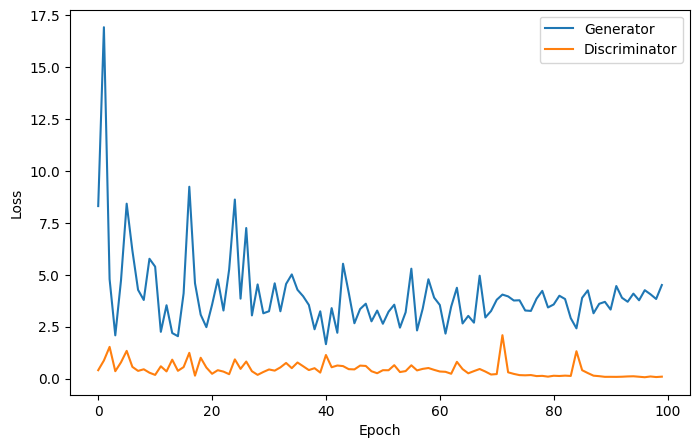

In [36]:
plt.figure(figsize=(8,5))

plt.plot(g_losses,label="Generator")

plt.plot(d_losses,label="Discriminator")

plt.legend()

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()

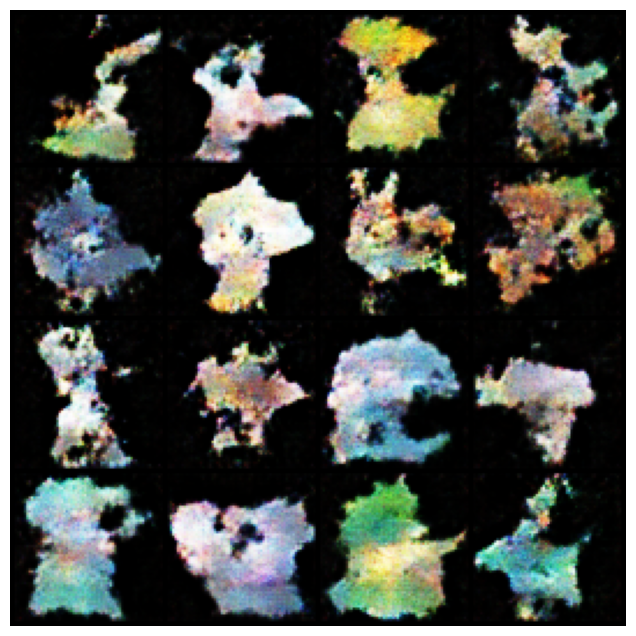

In [37]:
G.eval()

with torch.no_grad():

    noise = torch.randn(
        16,
        nz,
        1,
        1,
        device=device
    )

    fake = G(noise).cpu()

plt.figure(figsize=(8,8))

plt.axis("off")

plt.imshow(
    utils.make_grid(
        fake,
        nrow=4,
        normalize=True
    ).permute(1,2,0)
)

plt.show()